# E-Commerce Data: Distributed Analytics and Storage via Spark, HBase, and MongoDB

## Data Pipeline Initialization & Preprocessing

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os

os.environ['PYSPARK_PYTHON'] = r'C:\Python311\python.exe'
os.environ['JAVA_HOME'] = r'C:\Java\jdk'

# Create Spark Session
spark = SparkSession.builder \
    .master("local[2]") \
    .appName("ECommerce Analytics") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Load all data
sessions_df = spark.read.json("hdfs://localhost:9000/ecommerce/sessions/sessions_0.json")
transactions_df = spark.read.json("hdfs://localhost:9000/ecommerce/transactions/transactions.json")
users_df = spark.read.json("hdfs://localhost:9000/ecommerce/users/users.json")
products_df = spark.read.json("hdfs://localhost:9000/ecommerce/products/products.json")
categories_df = spark.read.json("hdfs://localhost:9000/ecommerce/categories/categories.json")

# Clean sessions
sessions_clean = sessions_df.select(
    "session_id", "user_id", "start_time", "duration_seconds",
    "conversion_status", "referrer",
    F.col("device_profile.type").alias("device_type"),
    F.col("device_profile.os").alias("device_os"),
    F.col("geo_data.city").alias("city"),
    F.col("geo_data.state").alias("state")
).dropna(subset=["user_id", "session_id", "start_time"])

# Cache
sessions_clean.cache()
transactions_df.cache()

# Register views
sessions_clean.createOrReplaceTempView("sessions")
transactions_df.createOrReplaceTempView("transactions")
users_df.createOrReplaceTempView("users")
products_df.createOrReplaceTempView("products")
categories_df.createOrReplaceTempView("categories")

print(f"Spark version: {spark.version}")
print(f"Sessions: {sessions_clean.count():,}")
print(f"Transactions: {transactions_df.count():,}")
print("Ready for Spark SQL!")

Spark version: 3.3.4
Sessions: 100,000
Transactions: 500,000
Ready for Spark SQL!


## Connecting to HBase

In [5]:
import happybase
# Before runnin the above import, make sure you install happybase thrift (!pip install happybase thrift)
# Connect to HBase ---
connection = happybase.Connection('localhost', port=9090)
connection.open()
table = connection.table('user_sessions')
print("Connected to HBase!")

Connected to HBase!


## Loading Each Session into HBase

In [6]:
# --- 2. Load each session into HBase ---
count = 0
batch = table.batch(batch_size=500)

for row in sessions_clean.collect():
    
    # Create row key: user_id + reversed time (recent sessions come first)
    dt = datetime.datetime.fromisoformat(row['start_time'])
    reversed_time = 99999999999999 - int(dt.timestamp() * 1000)
    row_key = f"{row['user_id']}_{reversed_time}".encode()
    
    # Store session data in column families
    batch.put(row_key, {
        b'session_info:session_id' : str(row['session_id']).encode(),
        b'session_info:start_time' : str(row['start_time']).encode(),
        b'session_info:duration'   : str(row['duration_seconds']).encode(),
        b'session_info:conversion' : str(row['conversion_status']).encode(),
        b'session_info:referrer'   : str(row['referrer']).encode(),
        b'device:type'             : str(row['type']).encode(),
        b'device:os'               : str(row['os']).encode(),
        b'geo:city'                : str(row['city']).encode(),
        b'geo:state'               : str(row['state']).encode(),
    })
    count += 1

# --- 3. Send batch and close ---
batch.send()
print(f"Done! {count:,} sessions loaded into HBase!")
connection.close()

Done! 100,000 sessions loaded into HBase!


## A Spark query to print top 10 products by Revenu

In [3]:
print("=== Top 10 Products by Revenue ===")
top_products = spark.sql("""
    SELECT 
        item.product_id,
        COUNT(*) as times_sold,
        SUM(item.quantity) as total_units,
        ROUND(SUM(item.subtotal), 2) as total_revenue
    FROM transactions
    LATERAL VIEW explode(items) t AS item
    GROUP BY item.product_id
    ORDER BY total_revenue DESC
    LIMIT 10
""")
top_products.show()

=== Top 10 Products by Revenue ===
+----------+----------+-----------+-------------+
|product_id|times_sold|total_units|total_revenue|
+----------+----------+-----------+-------------+
|prod_00154|       281|        578|     343418.7|
|prod_00253|       293|        609|    332124.24|
|prod_02908|       285|        587|    328168.22|
|prod_01652|       290|        584|     327828.4|
|prod_02303|       290|        575|    326893.25|
|prod_02419|       286|        577|    324262.46|
|prod_00967|       287|        593|    323475.57|
|prod_03324|       292|        561|    323438.94|
|prod_03061|       280|        569|    318890.36|
|prod_03278|       288|        587|    315483.15|
+----------+----------+-----------+-------------+



## Spark Query to show Revenue by Month

In [4]:
print("=== Monthly Revenue Trend ===")
spark.sql("""
    SELECT 
        SUBSTRING(timestamp, 1, 7) as month,
        COUNT(*) as num_transactions,
        ROUND(SUM(total), 2) as revenue,
        ROUND(AVG(total), 2) as avg_order_value
    FROM transactions
    GROUP BY SUBSTRING(timestamp, 1, 7)
    ORDER BY month
""").show()

=== Monthly Revenue Trend ===
+-------+----------------+--------------+---------------+
|  month|num_transactions|       revenue|avg_order_value|
+-------+----------------+--------------+---------------+
|2026-03|           30339|  2.83552033E7|         934.61|
|2026-04|          166766| 1.555654936E8|         932.84|
|2026-05|          171716|1.6007972427E8|         932.24|
|2026-06|          131179|1.2257574205E8|         934.42|
+-------+----------------+--------------+---------------+



## Query for Session conversion Analysis

In [5]:
print("=== Session Conversion Analysis ===")
spark.sql("""
    SELECT 
        conversion_status,
        COUNT(*) as num_sessions,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage,
        ROUND(AVG(duration_seconds) / 60, 2) as avg_duration_minutes
    FROM sessions
    GROUP BY conversion_status
    ORDER BY num_sessions DESC
""").show()

=== Session Conversion Analysis ===
+-----------------+------------+----------+--------------------+
|conversion_status|num_sessions|percentage|avg_duration_minutes|
+-----------------+------------+----------+--------------------+
|        abandoned|       44700|     44.70|               30.25|
|          browsed|       35061|     35.06|               30.18|
|        converted|       20239|     20.24|               30.08|
+-----------------+------------+----------+--------------------+



## QUery for Device Usage Analysis

In [6]:
print("=== Device Usage Analysis ===")
spark.sql("""
    SELECT 
        device_type,
        device_os,
        COUNT(*) as num_sessions,
        ROUND(AVG(duration_seconds) / 60, 2) as avg_duration_min,
        SUM(CASE WHEN conversion_status = 'converted' THEN 1 ELSE 0 END) as conversions
    FROM sessions
    GROUP BY device_type, device_os
    ORDER BY num_sessions DESC
""").show()

=== Device Usage Analysis ===
+-----------+---------+------------+----------------+-----------+
|device_type|device_os|num_sessions|avg_duration_min|conversions|
+-----------+---------+------------+----------------+-----------+
|     tablet|    macOS|        8490|           30.53|       1725|
|    desktop|  Windows|        8400|            29.8|       1637|
|     mobile|    macOS|        8374|            30.0|       1658|
|    desktop|  Android|        8374|           29.96|       1742|
|    desktop|      iOS|        8352|           30.39|       1711|
|     mobile|      iOS|        8346|           29.99|       1728|
|     tablet|      iOS|        8346|           30.28|       1672|
|    desktop|    macOS|        8310|           30.39|       1706|
|     tablet|  Android|        8309|           30.19|       1690|
|     mobile|  Windows|        8276|           29.99|       1641|
|     tablet|  Windows|        8225|            30.3|       1665|
|     mobile|  Android|        8198|          

## Query for  User Segmentation by Referrer

In [7]:
print("=== Sessions by Referrer Source ===")
spark.sql("""
    SELECT 
        referrer,
        COUNT(*) as num_sessions,
        SUM(CASE WHEN conversion_status = 'converted' THEN 1 ELSE 0 END) as conversions,
        ROUND(SUM(CASE WHEN conversion_status = 'converted' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as conversion_rate
    FROM sessions
    GROUP BY referrer
    ORDER BY num_sessions DESC
""").show()

=== Sessions by Referrer Source ===
+-------------+------------+-----------+---------------+
|     referrer|num_sessions|conversions|conversion_rate|
+-------------+------------+-----------+---------------+
|       direct|       20094|       4095|          20.38|
|        email|       20066|       3918|          19.53|
|    affiliate|       20027|       4111|          20.53|
|       social|       19989|       4010|          20.06|
|search_engine|       19824|       4105|          20.71|
+-------------+------------+-----------+---------------+



## BATCH PROCESSING:  Product Recommendation
# "Users who bought X also bought Y"

In [14]:
print("=== Product Recommendation Indicators ===")
product_pairs = spark.sql("""
    SELECT a.product_id as product_a, 
           b.product_id as product_b,
           COUNT(*) as times_bought_together
    FROM (
        SELECT transaction_id, item.product_id
        FROM transactions
        LATERAL VIEW explode(items) t AS item
    ) a
    JOIN (
        SELECT transaction_id, item.product_id
        FROM transactions
        LATERAL VIEW explode(items) t AS item
    ) b 
    ON a.transaction_id = b.transaction_id
    AND a.product_id < b.product_id
    GROUP BY a.product_id, b.product_id
    ORDER BY times_bought_together DESC
    LIMIT 10
""")
product_pairs.show()

=== Product Recommendation Indicators ===
+----------+----------+---------------------+
| product_a| product_b|times_bought_together|
+----------+----------+---------------------+
|prod_02483|prod_02898|                    5|
|prod_03836|prod_04523|                    4|
|prod_01527|prod_04212|                    4|
|prod_01677|prod_04867|                    4|
|prod_00297|prod_03662|                    4|
|prod_00335|prod_04369|                    4|
|prod_00950|prod_01968|                    3|
|prod_00993|prod_04785|                    3|
|prod_02365|prod_04308|                    3|
|prod_01652|prod_03882|                    3|
+----------+----------+---------------------+



## Integrated Analytical Query

In [10]:
print("=== Customer Lifetime Value Estimation ===")
print("Business Question: Who are our most valuable customers?")
print("Data Sources: transactions (MongoDB) + users (MongoDB) + sessions (HBase/Spark)")
print()

#  Calculate total spend per user from transactions
user_spend = spark.sql("""
    SELECT 
        user_id,
        COUNT(*) as total_orders,
        ROUND(SUM(total), 2) as total_spend,
        ROUND(AVG(total), 2) as avg_order_value,
        MIN(timestamp) as first_purchase,
        MAX(timestamp) as last_purchase
    FROM transactions
    GROUP BY user_id
""")
user_spend.createOrReplaceTempView("user_spend")
print("Step 1: User spend calculated from transactions")

# Get user engagement from sessions (simulating HBase data)
user_engagement = spark.sql("""
    SELECT 
        user_id,
        COUNT(*) as total_sessions,
        ROUND(AVG(duration_seconds) / 60, 2) as avg_session_minutes,
        SUM(CASE WHEN conversion_status = 'converted' THEN 1 ELSE 0 END) as converted_sessions
    FROM sessions
    GROUP BY user_id
""")
user_engagement.createOrReplaceTempView("user_engagement")
print("Step 2: User engagement calculated from sessions (HBase)")

# Join user profiles + spend + engagement
clv = spark.sql("""
    SELECT 
        u.user_id,
        u.geo_data.state as state,
        COALESCE(s.total_orders, 0) as total_orders,
        COALESCE(s.total_spend, 0) as total_spend,
        COALESCE(s.avg_order_value, 0) as avg_order_value,
        COALESCE(e.total_sessions, 0) as total_sessions,
        COALESCE(e.avg_session_minutes, 0) as avg_session_minutes,
        ROUND(COALESCE(s.total_spend, 0) * 
              (1 + COALESCE(e.total_sessions, 0) * 0.01), 2) as estimated_clv
    FROM users u
    LEFT JOIN user_spend s ON u.user_id = s.user_id
    LEFT JOIN user_engagement e ON u.user_id = e.user_id
    ORDER BY estimated_clv DESC
    LIMIT 10
""")

print("=== Top 10 Customers by Estimated CLV ===")
clv.show()

=== Customer Lifetime Value Estimation ===
Business Question: Who are our most valuable customers?
Data Sources: transactions (MongoDB) + users (MongoDB) + sessions (HBase/Spark)

Step 1: User spend calculated from transactions
Step 2: User engagement calculated from sessions (HBase)
=== Top 10 Customers by Estimated CLV ===
+-----------+-----+------------+-----------+---------------+--------------+-------------------+-------------+
|    user_id|state|total_orders|total_spend|avg_order_value|total_sessions|avg_session_minutes|estimated_clv|
+-----------+-----+------------+-----------+---------------+--------------+-------------------+-------------+
|user_004099|   NJ|          74|   79297.58|        1071.59|            17|              31.55|     92778.17|
|user_001824|   AZ|          74|   78556.86|        1061.58|            15|               35.1|     90340.39|
|user_001840|   MS|          79|   76244.69|         965.12|            15|              24.98|     87681.39|
|user_005418|

## Loading data for visualizations

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load saved results
output_path = r"C:\Users\HP\OneDrive\Desktop\E-Commerce Project\results"
viz_path = r"C:\Users\HP\OneDrive\Desktop\E-Commerce Project\visualizations"
import os
os.makedirs(viz_path, exist_ok=True)

top_products_df = pd.read_csv(f"{output_path}\\top_products.csv")
monthly_df = pd.read_csv(f"{output_path}\\monthly_revenue.csv")
conversion_df = pd.read_csv(f"{output_path}\\conversion.csv")
referrer_df = pd.read_csv(f"{output_path}\\referrer.csv")
clv_df = pd.read_csv(f"{output_path}\\clv.csv")

print("Data loaded for visualizations!")
print(f"Top products: {len(top_products_df)} rows")
print(f"Monthly revenue: {len(monthly_df)} rows")
print(f"Conversion: {len(conversion_df)} rows")
print(f"Referrer: {len(referrer_df)} rows")
print(f"CLV: {len(clv_df)} rows")

Matplotlib is building the font cache; this may take a moment.


Data loaded for visualizations!
Top products: 10 rows
Monthly revenue: 4 rows
Conversion: 3 rows
Referrer: 5 rows
CLV: 10 rows


## Saving the results respectively using Spark sql

In [11]:
output_path = r"C:\Users\HP\OneDrive\Desktop\E-Commerce Project\results"
os.makedirs(output_path, exist_ok=True)

top_products.toPandas().to_csv(f"{output_path}\\top_products.csv", index=False)
clv.toPandas().to_csv(f"{output_path}\\clv.csv", index=False)

spark.sql("""
    SELECT SUBSTRING(timestamp, 1, 7) as month,
    COUNT(*) as num_transactions, ROUND(SUM(total), 2) as revenue
    FROM transactions
    GROUP BY SUBSTRING(timestamp, 1, 7) ORDER BY month
""").toPandas().to_csv(f"{output_path}\\monthly_revenue.csv", index=False)

spark.sql("""
    SELECT conversion_status, COUNT(*) as num_sessions,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
    FROM sessions GROUP BY conversion_status
""").toPandas().to_csv(f"{output_path}\\conversion.csv", index=False)

spark.sql("""
    SELECT referrer, COUNT(*) as num_sessions,
    ROUND(SUM(CASE WHEN conversion_status = 'converted' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) as conversion_rate
    FROM sessions GROUP BY referrer
""").toPandas().to_csv(f"{output_path}\\referrer.csv", index=False)

print("All results saved!")

All results saved!


## Visualizations

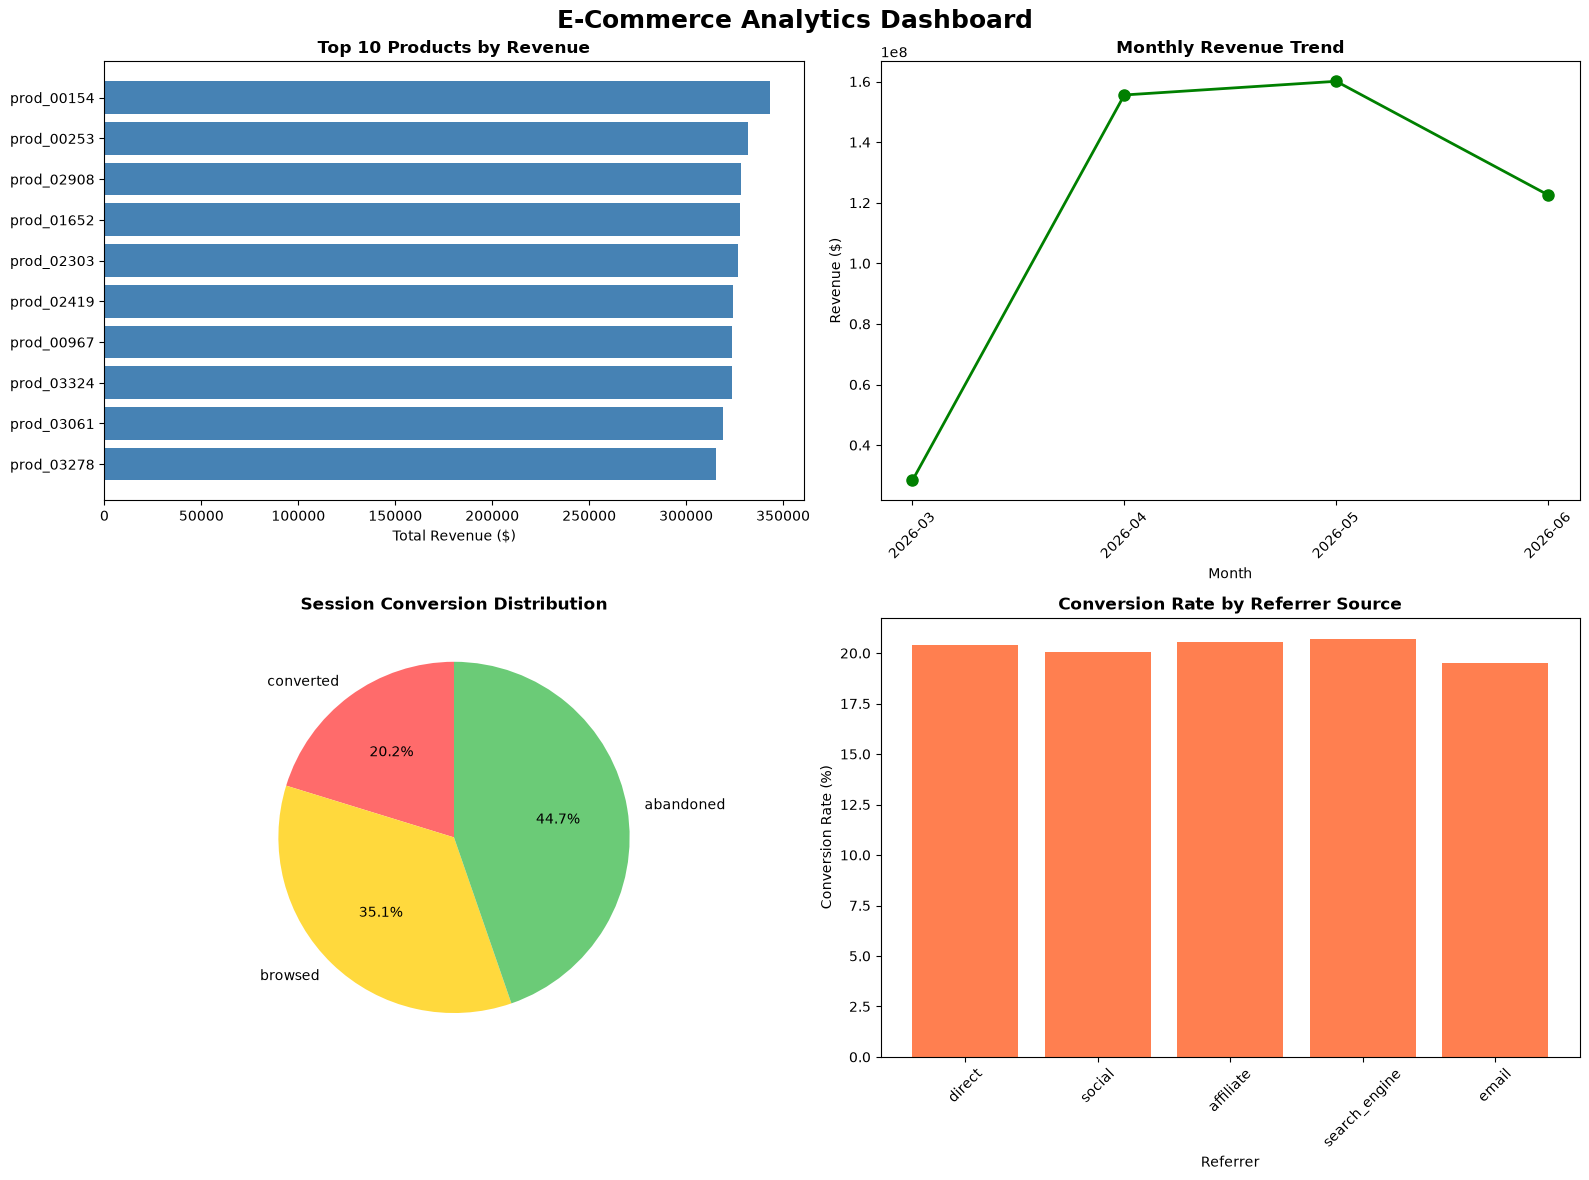

Dashboard saved!


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('E-Commerce Analytics Dashboard', fontsize=18, fontweight='bold')

# Chart 1: Top 10 Products by Revenue
axes[0, 0].barh(top_products_df['product_id'], 
                top_products_df['total_revenue'], 
                color='steelblue')
axes[0, 0].set_title('Top 10 Products by Revenue', fontweight='bold')
axes[0, 0].set_xlabel('Total Revenue ($)')
axes[0, 0].invert_yaxis()

# Chart 2: Monthly Revenue Trend
axes[0, 1].plot(monthly_df['month'], monthly_df['revenue'], 
                marker='o', color='green', linewidth=2, markersize=8)
axes[0, 1].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Chart 3: Session Conversion Funnel
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
axes[1, 0].pie(conversion_df['num_sessions'], 
               labels=conversion_df['conversion_status'],
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 0].set_title('Session Conversion Distribution', fontweight='bold')

# Chart 4: Conversion Rate by Referrer
axes[1, 1].bar(referrer_df['referrer'], 
               referrer_df['conversion_rate'],
               color='coral')
axes[1, 1].set_title('Conversion Rate by Referrer Source', fontweight='bold')
axes[1, 1].set_xlabel('Referrer')
axes[1, 1].set_ylabel('Conversion Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{viz_path}\\dashboard.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")